# `m_x` forced-acceleration CFD 后处理

本 notebook 使用修正后的 Javanmard procedure two 数据重新计算 surge 方向的 added-mass scalar。

本轮主数据源：

- `mx_mid_accel_5.5s_1_00275_time_fx_inlet_velocity_20260619_005716.csv`
- 列含义：`time_s`、`fx_N`、`inlet_velocity_mps`

核心要求：

1. 初始低速段用 \(F_{x,0}\) 表示；
2. \(F_{x,3}\) 必须取减速过程中速度再次等于 \(V_0\) 的时刻；
3. 对当前修正速度曲线，\(t_3=5.0\,\mathrm{s}\)，此时 \(V=1.0\,\mathrm{m\,s^{-1}}\)，且减速度仍为 \(-0.25\,\mathrm{m\,s^{-2}}\)；
4. 先识别 \(-X_{\dot u}\)，再换算论文中使用的 \(m_x=m-X_{\dot u}=m+(-X_{\dot u})\)。


## 1. 计算公式

Javanmard procedure two 的计算逻辑是，在同一速度 \(V_0\) 下比较初始低速恒速状态和减速过程中的力：

$$
\left|F_{t=t_3}-F_{t<t_0}\right|=(\rho V_d+m_a)|a|.
$$

因此 surge 方向的正 added-mass scalar 为：

$$
-X_{\dot u}
=
\frac{\left|F_{x,3}-F_{x,0}\right|}{|a|}
-\rho V_d.
$$

论文动力学中使用的有效 surge 惯性为：

$$
m_x=m-X_{\dot u}=m+(-X_{\dot u}).
$$


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

# --- Physical constants and extraction settings ---
RHO = 997.561              # kg/m^3
V_DISPLACED = 0.002576     # m^3
BODY_MASS_KG = 2.55        # kg
ABS_ACCEL = 0.25           # m/s^2
V0 = 1.0                   # m/s
F0_WINDOW = (1.8, 2.0)     # s
F3_TIME = 5.0              # s, velocity re-crosses V0 during deceleration

DATA_SUBDIR = "mx_data"
CORRECTED_FORCE_FILE = "mx_mid_accel_5.5s_1_00275_time_fx_inlet_velocity_20260619_005716.csv"
HIGH_ACCEL_SUMMARY_FILE = "mx_highaccle_result_summary.csv"

CANONICAL_RESULT_FILE = "mx_result_summary.csv"
CORRECTED_RESULT_FILE = "mx_javanmard_corrected_result_summary.csv"
COMPARISON_FILE = "mx_javanmard_corrected_vs_highaccle_comparison.csv"


def find_base_dir() -> Path:
    cwd = Path.cwd()
    candidates = [
        cwd / "mx_mz_calc",
        cwd,
        cwd.parent / "mx_mz_calc",
        Path(r"C:\AD_v2_stage1_analysis\mx_mz_calc"),
    ]
    for candidate in candidates:
        if (candidate / DATA_SUBDIR / CORRECTED_FORCE_FILE).exists():
            return candidate
    raise FileNotFoundError(f"Cannot locate {DATA_SUBDIR}/{CORRECTED_FORCE_FILE} from {cwd}")


BASE_DIR = find_base_dir()
DATA_DIR = BASE_DIR / DATA_SUBDIR

print(f"BASE_DIR = {BASE_DIR}")
print(f"DATA_DIR = {DATA_DIR}")
print(f"Corrected data = {CORRECTED_FORCE_FILE}")
print(f"High-accel summary = {HIGH_ACCEL_SUMMARY_FILE}")


BASE_DIR = C:\AD_v2_stage1_analysis\mx_mz_calc
DATA_DIR = C:\AD_v2_stage1_analysis\mx_mz_calc\mx_data
Corrected data = mx_mid_accel_5.5s_1_00275_time_fx_inlet_velocity_20260619_005716.csv
High-accel summary = mx_highaccle_result_summary.csv


In [2]:
force_time = pd.read_csv(DATA_DIR / CORRECTED_FORCE_FILE)

required_cols = {"time_s", "fx_N", "inlet_velocity_mps"}
missing = required_cols - set(force_time.columns)
assert not missing, f"{CORRECTED_FORCE_FILE} 缺少列: {missing}"

force_time = force_time.copy()
for col in ["time_s", "fx_N", "inlet_velocity_mps"]:
    force_time[col] = pd.to_numeric(force_time[col], errors="coerce")

force_time = force_time.dropna(subset=["time_s", "fx_N", "inlet_velocity_mps"]).sort_values("time_s")
force_time["time_step_index"] = np.arange(1, len(force_time) + 1)

print(f"Rows: {len(force_time)}")
print(f"Time range: {force_time['time_s'].min():.3f} -- {force_time['time_s'].max():.3f} s")
print(f"Velocity range: {force_time['inlet_velocity_mps'].min():.3f} -- {force_time['inlet_velocity_mps'].max():.3f} m/s")
display(force_time.head())
display(force_time.tail())


Rows: 275
Time range: 0.020 -- 5.500 s
Velocity range: 0.875 -- 1.250 m/s


,time_s,fx_N,inlet_velocity_mps,time_step_index
0,0.02,-1.06702,1,1
1,0.04,-1.05974,1,2
2,0.06,-1.05388,1,3
3,0.08,-1.04941,1,4
4,0.1,-1.04564,1,5


,time_s,fx_N,inlet_velocity_mps,time_step_index
270,5.42,0.246621,0.895,271
271,5.44,0.252909,0.89,272
272,5.46,0.259268,0.885,273
273,5.48,0.265682,0.88,274
274,5.5,0.27221,0.875,275


## 2. 速度曲线核查

本算例对应的速度历史：

- \(0\)--\(2\,\mathrm{s}\)：\(V=1.0\,\mathrm{m\,s^{-1}}\)；
- \(2\)--\(3\,\mathrm{s}\)：线性加速到 \(1.25\,\mathrm{m\,s^{-1}}\)；
- \(3\)--\(4\,\mathrm{s}\)：高速平台 \(V=1.25\,\mathrm{m\,s^{-1}}\)；
- \(4\)--\(5.5\,\mathrm{s}\)：继续线性减速，减速段穿过 \(V_0\)；
- \(t_3=5.0\,\mathrm{s}\)：\(V(t_3)=V_0=1.0\,\mathrm{m\,s^{-1}}\)，并且仍处于减速段内。


In [3]:
key_times = [1.8, 2.0, 3.0, 4.0, 5.0, 5.5]
key_rows = []
for target in key_times:
    idx = (force_time["time_s"] - target).abs().idxmin()
    row = force_time.loc[idx]
    key_rows.append(
        {
            "target_time_s": target,
            "actual_time_s": float(row["time_s"]),
            "Fx_N": float(row["fx_N"]),
            "inlet_velocity_mps": float(row["inlet_velocity_mps"]),
            "abs_time_error_s": abs(float(row["time_s"]) - target),
        }
    )

velocity_check = pd.DataFrame(key_rows)
display(velocity_check)

f3_velocity = float(velocity_check.loc[np.isclose(velocity_check["target_time_s"], F3_TIME), "inlet_velocity_mps"].iloc[0])
assert abs(f3_velocity - V0) < 1e-9, f"t3 速度应等于 V0={V0}, 实际为 {f3_velocity}"


,target_time_s,actual_time_s,Fx_N,inlet_velocity_mps,abs_time_error_s
0,1.8,1.8,-0.799804,1,0
1,2,2,-0.796505,1,0
2,3,3,-2.16772,1.25,0
3,4,4,-1.25335,1.25,0
4,5,5,0.105168,1,2.04281e-14
5,5.5,5.5,0.27221,0.875,3.01981e-14


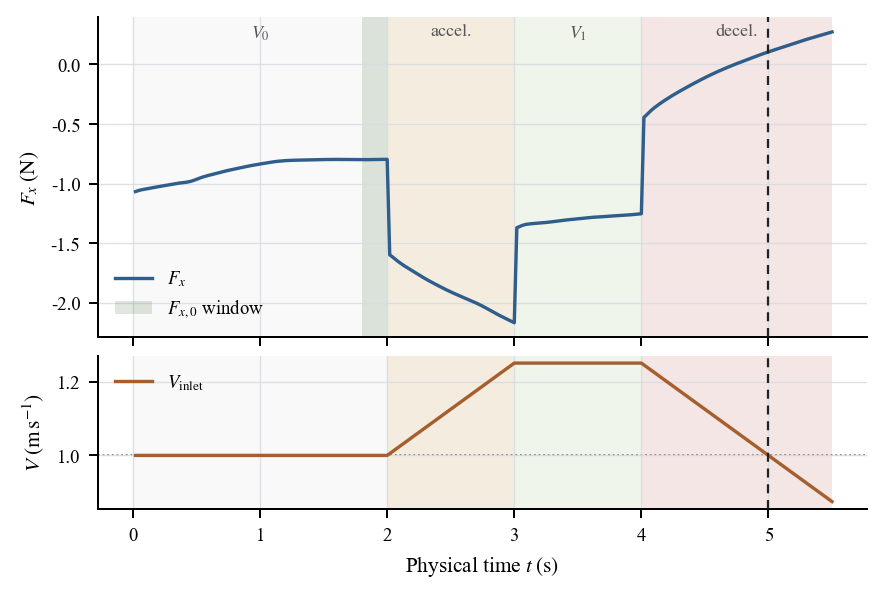

In [4]:
CM = 1.0 / 2.54
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False,
        "figure.dpi": 180,
        "axes.labelsize": 8.5,
        "axes.titlesize": 9.0,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "legend.fontsize": 7.5,
        "axes.linewidth": 0.8,
    }
)

fig, (ax_force, ax_speed) = plt.subplots(
    2,
    1,
    figsize=(14 * CM, 9 * CM),
    sharex=True,
    gridspec_kw={"height_ratios": [2.1, 1.0], "hspace": 0.08},
)

phase_specs = [
    (0.0, 2.0, "#F2F3F5", r"$V_0$"),
    (2.0, 3.0, "#E7D7B8", "accel."),
    (3.0, 4.0, "#DCE9D3", r"$V_1$"),
    (4.0, 5.5, "#E8C9C5", "decel."),
]
for ax in (ax_force, ax_speed):
    for start, end, color, _ in phase_specs:
        ax.axvspan(start, end, color=color, alpha=0.45, lw=0, zorder=0)
    ax.grid(True, which="major", color="#D7DCE2", lw=0.55, alpha=0.85)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axvline(F3_TIME, color="#222222", ls=(0, (4, 3)), lw=0.9, zorder=5)

for start, end, _, label in phase_specs:
    ax_force.text(
        0.5 * (start + end),
        0.98,
        label,
        transform=ax_force.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=7.2,
        color="#555555",
    )

ax_force.plot(force_time["time_s"], force_time["fx_N"], color="#2F5D8C", lw=1.35, label=r"$F_x$")
ax_force.axvspan(F0_WINDOW[0], F0_WINDOW[1], color="#587D4A", alpha=0.18, lw=0, label=r"$F_{x,0}$ window")
ax_force.set_ylabel(r"$F_x\;(\mathrm{N})$")
ax_force.legend(loc="best", frameon=False)

ax_speed.plot(force_time["time_s"], force_time["inlet_velocity_mps"], color="#A65E2E", lw=1.35, label=r"$V_{\mathrm{inlet}}$")
ax_speed.axhline(V0, color="#777777", lw=0.7, ls=":", zorder=1)
ax_speed.set_ylabel(r"$V\;(\mathrm{m\,s^{-1}})$")
ax_speed.set_xlabel(r"Physical time $t\;(\mathrm{s})$")
ax_speed.legend(loc="best", frameon=False)

plt.show()


## 3. 提取 \(F_{x,0}\) 和 \(F_{x,3}\)

采用以下定义：

- \(F_{x,0}\)：\(t=1.8\)--\(2.0\,\mathrm{s}\) 初始低速平台窗口均值；
- \(F_{x,3}\)：\(t_3=5.0\,\mathrm{s}\) 单点值；此时速度再次等于 \(V_0\)，并且减速仍未结束。


In [5]:
t = force_time["time_s"]

f0_mask = (t >= F0_WINDOW[0]) & (t <= F0_WINDOW[1])
f0_df = force_time.loc[f0_mask].copy()
assert len(f0_df) > 0, "F0 窗口内没有数据"

F0 = float(f0_df["fx_N"].mean())
F0_STD = float(f0_df["fx_N"].std(ddof=0))
F0_N = int(len(f0_df))

f3_idx = (force_time["time_s"] - F3_TIME).abs().idxmin()
f3_row = force_time.loc[f3_idx].copy()
assert abs(float(f3_row["time_s"]) - F3_TIME) < 1e-8, f"没有找到 t3={F3_TIME} s 的精确数据点"
assert abs(float(f3_row["inlet_velocity_mps"]) - V0) < 1e-8, "t3 速度没有回到 V0"

F3 = float(f3_row["fx_N"])
F3_V = float(f3_row["inlet_velocity_mps"])

extract_table = pd.DataFrame(
    [
        {"item": r"$F_{x,0}$ window", "value": f"{F0_WINDOW[0]}--{F0_WINDOW[1]}", "unit": "s"},
        {"item": r"$F_{x,0}$ samples", "value": F0_N, "unit": "time steps"},
        {"item": r"$F_{x,0}$ mean", "value": F0, "unit": "N"},
        {"item": r"$F_{x,0}$ std", "value": F0_STD, "unit": "N"},
        {"item": r"$F_{x,3}$ time", "value": float(f3_row["time_s"]), "unit": "s"},
        {"item": r"$F_{x,3}$ velocity", "value": F3_V, "unit": "m/s"},
        {"item": r"$F_{x,3}$", "value": F3, "unit": "N"},
    ]
)
display(extract_table)


,item,value,unit
0,"$F_{x,0}$ window",1.8--2.0,s
1,"$F_{x,0}$ samples",11,time steps
2,"$F_{x,0}$ mean",-0.79805,N
3,"$F_{x,0}$ std",0.00119806,N
4,"$F_{x,3}$ time",5,s
5,"$F_{x,3}$ velocity",1,m/s
6,"$F_{x,3}$",0.105168,N


## 4. 计算 \(-X_{\dot u}\) 和 \(m_x\)

这里的 CFD 后处理首先得到的是 \(-X_{\dot u}\)，不是直接测量 \(m_x\)。论文中的 \(m_x\) 由 \(m_x=m-X_{\dot u}\) 换算得到。


In [6]:
delta_F = abs(F3 - F0)
apparent_mass = delta_F / ABS_ACCEL
displaced_mass = RHO * V_DISPLACED
minus_X_dot_u = apparent_mass - displaced_mass
X_dot_u = -minus_X_dot_u
mx_effective = BODY_MASS_KG + minus_X_dot_u

result = pd.DataFrame(
    [
        {"symbol": r"$F_{x,0}$", "value": F0, "unit": "N", "meaning": "低速恒速窗口均值"},
        {"symbol": r"$F_{x,3}$", "value": F3, "unit": "N", "meaning": "减速过程中 V=V0 时的力"},
        {"symbol": r"$\lvert F_{x,3}-F_{x,0}\rvert$", "value": delta_F, "unit": "N", "meaning": "同速力差"},
        {"symbol": r"$\lvert a\rvert$", "value": ABS_ACCEL, "unit": "m/s^2", "meaning": "加速度幅值"},
        {"symbol": r"$\lvert\Delta F\rvert/\lvert a\rvert$", "value": apparent_mass, "unit": "kg", "meaning": "表观加速度质量"},
        {"symbol": r"$\rho V_d$", "value": displaced_mass, "unit": "kg", "meaning": "排水质量扣除项"},
        {"symbol": r"$-X_{\dot u}$", "value": minus_X_dot_u, "unit": "kg", "meaning": "CFD 识别的正 added-mass scalar"},
        {"symbol": r"$X_{\dot u}$", "value": X_dot_u, "unit": "kg", "meaning": "Fossen 记号中的导数项"},
        {"symbol": r"$m_x$", "value": mx_effective, "unit": "kg", "meaning": "论文模型使用的有效 surge 惯性"},
    ]
)

display(result)

for filename in [CORRECTED_RESULT_FILE, CANONICAL_RESULT_FILE]:
    out_path = DATA_DIR / filename
    result.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"Saved: {out_path}")


,symbol,value,unit,meaning
0,"$F_{x,0}$",-0.79805,N,低速恒速窗口均值
1,"$F_{x,3}$",0.105168,N,减速过程中 V=V0 时的力
2,"$\lvert F_{x,3}-F_{x,0}\rvert$",0.903218,N,同速力差
3,$\lvert a\rvert$,0.25,m/s^2,加速度幅值
4,$\lvert\Delta F\rvert/\lvert a\rvert$,3.61287,kg,表观加速度质量
5,$\rho V_d$,2.56972,kg,排水质量扣除项
6,$-X_{\dot u}$,1.04316,kg,CFD 识别的正 added-mass scalar
7,$X_{\dot u}$,-1.04316,kg,Fossen 记号中的导数项
8,$m_x$,3.59316,kg,论文模型使用的有效 surge 惯性


Saved: C:\AD_v2_stage1_analysis\mx_mz_calc\mx_data\mx_javanmard_corrected_result_summary.csv
Saved: C:\AD_v2_stage1_analysis\mx_mz_calc\mx_data\mx_result_summary.csv


## 5. 与旧 high-accel 结果对比

这里的 high-accel summary 是之前 \(a=0.50\,\mathrm{m\,s^{-2}}\) 算例的结果。对比时重点看 \(-X_{\dot u}\)，因为它是 forced-acceleration CFD 直接识别出的 added-mass scalar；\(m_x\) 是进一步加上刚体质量后的模型参数。


In [ ]:
high_summary = pd.read_csv(DATA_DIR / HIGH_ACCEL_SUMMARY_FILE)
high_lookup = dict(zip(high_summary["symbol"], high_summary["value"]))

def high_value(symbol: str) -> float:
    if symbol not in high_lookup:
        raise KeyError(f"{symbol} not found in {HIGH_ACCEL_SUMMARY_FILE}")
    return float(high_lookup[symbol])


comparison_rows = [
    {
        "quantity": r"$F_{x,0}$",
        "corrected_a0p25": F0,
        "high_a0p50": high_value(r"$F_{x,0}$"),
        "unit": "N",
    },
    {
        "quantity": r"$F_{x,3}$",
        "corrected_a0p25": F3,
        "high_a0p50": high_value(r"$F_{x,3}$"),
        "unit": "N",
    },
    {
        "quantity": r"$\lvert F_{x,3}-F_{x,0}\rvert$",
        "corrected_a0p25": delta_F,
        "high_a0p50": high_value(r"$\lvert F_{x,3}-F_{x,0}\rvert$"),
        "unit": "N",
    },
    {
        "quantity": r"$\lvert a\rvert$",
        "corrected_a0p25": ABS_ACCEL,
        "high_a0p50": high_value(r"$\lvert a\rvert$"),
        "unit": "m/s^2",
    },
    {
        "quantity": r"$-X_{\dot u}$",
        "corrected_a0p25": minus_X_dot_u,
        "high_a0p50": high_value(r"$-X_{\dot u}$"),
        "unit": "kg",
    },
    {
        "quantity": r"$m_x$",
        "corrected_a0p25": mx_effective,
        "high_a0p50": high_value(r"$m_x$"),
        "unit": "kg",
    },
]

comparison = pd.DataFrame(comparison_rows)
comparison["high_minus_corrected"] = comparison["high_a0p50"] - comparison["corrected_a0p25"]
comparison["relative_to_corrected_percent"] = (
    comparison["high_minus_corrected"] / comparison["corrected_a0p25"].abs() * 100.0
)

display(comparison)



,quantity,corrected_a0p25,high_a0p50,unit,high_minus_corrected,relative_to_corrected_percent
0,"$F_{x,0}$",-0.79805,-0.79805,N,-5.01435e-09,-6.28325e-07
1,"$F_{x,3}$",0.105168,0.93222,N,0.827051,786.407
2,"$\lvert F_{x,3}-F_{x,0}\rvert$",0.903218,1.73027,N,0.827051,91.5671
3,$\lvert a\rvert$,0.25,0.5,m/s^2,0.25,100
4,$-X_{\dot u}$,1.04316,0.890822,kg,-0.152334,-14.6032
5,$m_x$,3.59316,3.44082,kg,-0.152334,-4.23957


Saved: C:\AD_v2_stage1_analysis\mx_mz_calc\mx_data\mx_javanmard_corrected_vs_highaccle_comparison.csv


## 6. 结果判断

本次修正后的 \(a=0.25\,\mathrm{m\,s^{-2}}\) Javanmard procedure-two 结果为：

- \(-X_{\dot u}\)：由 notebook 上方表格给出；
- \(X_{\dot u}=-(-X_{\dot u})\)；
- \(m_x=m-X_{\dot u}=m+(-X_{\dot u})\)。

与之前 high-accel 算例相比，\(-X_{\dot u}\) 的差异应作为加速度敏感性或历史效应影响来讨论，不应直接写成已经完成严格的加速度无关性验证。

当前 corrected \(a=0.25\) 算例满足 Javanmard procedure two 的关键取点条件：\(t_3=5.0\,\mathrm{s}\) 时速度等于 \(V_0\)，并且该点位于仍在继续的减速段内部。
